# Q5 Regression Pipeline (Batch Normalize 후 Regression)

## 목적
- Batch effect 제거 (batch normalization)
- Stable feature로 regression 수행
- RMSE 평가

이 notebook은 **EDA 이후 Modeling 단계**입니다.
Batch normalize는 Feature Engineering + Data Preprocessing 단계에 해당합니다.


## 1. 필요한 라이브러리 import

In [43]:
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error

import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import r2_score


## 2. Feature 선택

EDA에서 안정적이었던 feature만 사용


In [ ]:
features = [

'charge_time_mean',
'QDischarge_delta_100_10',
'IR_delta',
'QDischarge_delta',
'IR_mean',
'QDischarge_mean'

]

target = 'cycle_life'


## 3. Batch Normalize (핵심 단계)

Batch별 평균/표준편차로 normalize
논문에서도 batch effect 제거가 중요


In [45]:
df1 = pd.read_csv("../results/batch1_features.csv")

df2 = pd.read_csv("../results/batch2_features.csv")

df3 = pd.read_csv("../results/batch3_features.csv")

In [46]:
df1['batch']='B1'
df2['batch']='B2'
df3['batch']='B3'

In [47]:
df_all = pd.concat([df1,df2,df3])

In [48]:
df_all = df_all.dropna(subset=['cycle_life'])

df_all = df_all[df_all['Tmax_mean'] < 80]

In [49]:
def batch_normalize(df):

    df_norm = df.copy()

    cols = features   # feature만!

    df_norm[cols] = df.groupby('batch')[cols].transform(

        lambda x:(x-x.mean())/(x.std()+1e-8)

    )

    return df_norm

## 4. Train/Test split

In [50]:
df_norm = batch_normalize(df_all)

In [ ]:
# X = df_norm[features]

# y = df_norm[target]

# X_train,X_test,y_train,y_test = train_test_split(

#     X,y,test_size=0.2,random_state=42

# )


In [51]:
# ===== Batch based split =====

train_df = df_norm[df_norm['batch']!='B3']

test_df = df_norm[df_norm['batch']=='B3']


X_train = train_df[features]

y_train = train_df[target]


X_test = test_df[features]

y_test = test_df[target]


print("Train size:",len(X_train))

print("Test size:",len(X_test))

Train size: 85
Test size: 44


## 5. Linear Regression

In [52]:
df_all[df_all['cycle_life'].isna()]

,cycle_life,IR_mean,QDischarge_mean,Tmax_mean,Tavg_mean,charge_time_mean,IR_delta,QDischarge_delta,IR_delta_100_10,QDischarge_delta_100_10,IR_var,QDischarge_var,batch


In [53]:
df_norm.isna().sum()

cycle_life                 0
IR_mean                    0
QDischarge_mean            0
Tmax_mean                  0
Tavg_mean                  0
charge_time_mean           0
IR_delta                   0
QDischarge_delta           0
IR_delta_100_10            0
QDischarge_delta_100_10    0
IR_var                     0
QDischarge_var             0
batch                      0
dtype: int64

In [54]:
df_norm.shape

(129, 13)

In [55]:
lr = LinearRegression()

lr.fit(X_train,y_train)

pred_lr = lr.predict(X_test)

rmse_lr = np.sqrt(mean_squared_error(y_test,pred_lr))

print("Linear RMSE:",rmse_lr)


Linear RMSE: 479.77802430411197


In [56]:
mape_lr = np.mean(np.abs((y_test - pred_lr)/y_test))*100

print("Linear MAPE:",mape_lr,"%")

Linear MAPE: 34.62779287630052 %


## 6. Random Forest

In [57]:
rf = RandomForestRegressor(

    n_estimators=300,
    max_depth=6,
    random_state=42

)

rf.fit(X_train,y_train)

pred_rf = rf.predict(X_test)

rmse_rf = np.sqrt(mean_squared_error(y_test,pred_rf))

print("RF RMSE:",rmse_rf)


RF RMSE: 419.44432263117426


In [58]:
mape_rf = np.mean(np.abs((y_test - pred_rf)/y_test))*100

print("RF MAPE:",mape_rf,"%")

RF MAPE: 22.915341155503004 %


## 7. LightGBM

In [66]:
# ===== Batch based split =====

train_df = df_norm[df_norm['batch']!='B3']

test_df = df_norm[df_norm['batch']=='B3']


X_train = train_df[features]

y_train = train_df[target]


X_test = test_df[features]

y_test = test_df[target]


print("Train size:",len(X_train))

print("Test size:",len(X_test))

Train size: 85
Test size: 44


In [67]:
from lightgbm import LGBMRegressor

# Linear
lr.fit(X_train,y_train)

# RF
rf.fit(X_train,y_train)

# LightGBM ⭐
lgb = LGBMRegressor(
    n_estimators=300,
    learning_rate=0.05,
    max_depth=5,
    min_child_samples=5,
    verbose=-1
)

lgb.fit(X_train,y_train)

,boosting_type,'gbdt'
,num_leaves,31
,max_depth,5
,learning_rate,0.05
,n_estimators,300
,subsample_for_bin,200000
,objective,None
,class_weight,None
,min_split_gain,0.0
,min_child_weight,0.001
,min_child_samples,5


In [68]:
pred_lgb = lgb.predict(X_test)

rmse_lgb = np.sqrt(mean_squared_error(y_test,pred_lgb))

print("LightGBM RMSE:",rmse_lgb)

LightGBM RMSE: 463.5065537424435


In [69]:
mape_lgb = np.mean(np.abs((y_test - pred_lgb)/y_test))*100

print("LightGBM MAPE:",mape_lgb,"%")

LightGBM MAPE: 26.16184280576972 %


## 8. Feature Importance

In [70]:
importance = pd.Series(

rf.feature_importances_,
index=features

).sort_values(ascending=False)

importance


charge_time_mean           0.467313
IR_mean                    0.202921
IR_delta                   0.125360
QDischarge_delta_100_10    0.086628
QDischarge_mean            0.064563
QDischarge_delta           0.053214
dtype: float64

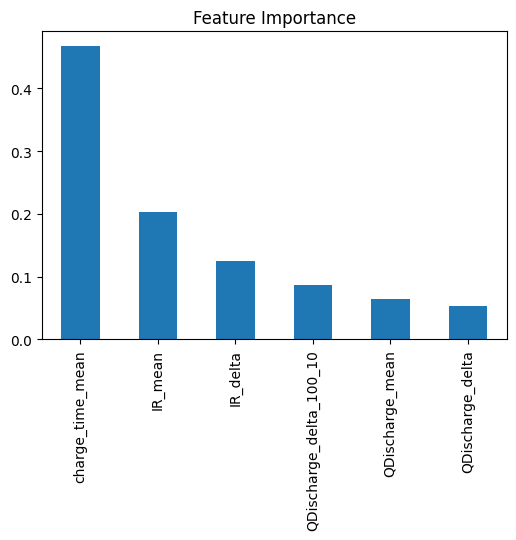

In [71]:
plt.figure(figsize=(6,4))

importance.plot(kind='bar')

plt.title("Feature Importance")

plt.show()


## 9. 실제값 vs 예측값

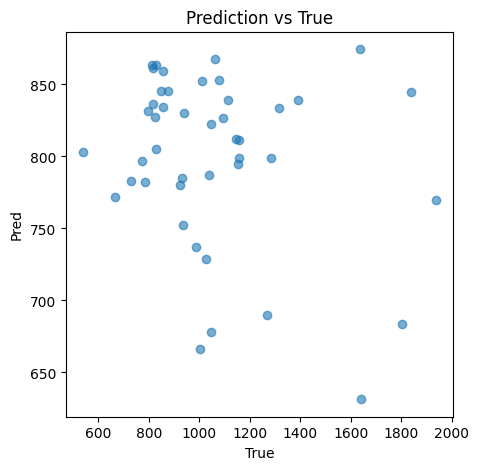

In [72]:
plt.figure(figsize=(5,5))

plt.scatter(y_test,pred_rf,alpha=0.6)

plt.xlabel("True")

plt.ylabel("Pred")

plt.title("Prediction vs True")

plt.show()
